# GraphGPS Curriculum Training for ResPlan

This notebook implements a clean ResPlan curriculum pipeline:

- HouseGAN++ style graph + component masks + condition mask/flag.
- ResPlan graph construction v2: adjacency stays a graph edge, only matched `via_door` edges become interior-door target nodes.
- GraphGPS generator from `model/graphgps_models.py`.
- Curriculum phases: rooms -> front door -> matched interior doors -> optional GAN refinement.
- Group-aware loss and validation metrics for room, front door, and interior door nodes.

The original `dataset/ResPlan.pkl` is not modified.


## 1. Setup / Config

Run this cell first. Change `selected_phase` when moving through the curriculum.


In [3]:
print(Path.cwd())

/jet/home/cfu2


In [ ]:
from pathlib import Path
import os
import sys
import math
import time
import json
import pickle
import copy
import contextlib
import random
from collections import Counter, defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dataset" / "ResPlan.pkl").exists():
    PROJECT_ROOT = Path(r"C:\Users\james\Desktop\11785_final")

DATASET_PATH = PROJECT_ROOT / "dataset" / "ResPlan.pkl"
CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
MODEL_ROOT = PROJECT_ROOT / "Final_Project"

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "dataset"))

from resplan_utils import normalize_keys, get_geometries, geometry_to_mask, plan_to_graph


from Final_Project.model.graphgps_models import (
    MODEL_NAME,
    Generator,
    Discriminator,
    compute_gradient_penalty,
)
from shapely import affinity
from shapely.geometry import Point


def seed_everything(seed=11785):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


GROUP_NAME_TO_ID = {"room": 0, "front_door": 1, "interior_door": 2}
ID_TO_GROUP_NAME = {v: k for k, v in GROUP_NAME_TO_ID.items()}

PHASE_PRESETS = {
    "phase_a1_rooms": {
        "load_checkpoint": None,
        "epochs": 15,
        "g_lr": 1e-4,
        "d_lr": 0.0,
        "active_groups": ["room"],
        "fixed_room_keep_prob": 0.35,
        "hard_copy_fixed_nodes": True,
    },
    "phase_a2_frontdoor": {
        "load_checkpoint": "phase_a1_best",
        "epochs": 10,
        "g_lr": 5e-5,
        "d_lr": 0.0,
        "active_groups": ["room", "front_door"],
        "fixed_room_keep_prob": 0.35,
        "hard_copy_fixed_nodes": True,
    },
    "phase_a3_matched_doors": {
        "load_checkpoint": "phase_a2_best",
        "epochs": 20,
        "g_lr": 3e-5,
        "d_lr": 0.0,
        "active_groups": ["room", "front_door", "interior_door"],
        "fixed_room_keep_prob": 0.35,
        "hard_copy_fixed_nodes": True,
    },
    "phase_b_gan_refine": {
        "load_checkpoint": "phase_a3_best",
        "epochs": 10,
        "g_lr": 2e-5,
        "d_lr": 5e-6,
        "active_groups": ["room", "front_door", "interior_door"],
        "fixed_room_keep_prob": 0.35,
        "hard_copy_fixed_nodes": True,
        "gan_adv_weight": 0.0005,
        "gan_recon_weight": 10.0,
        "gan_nonfixed_recon_weight": 15.0,
        "lambda_gp": 10.0,
        "n_critic": 1,
    },
}

# Start here. Move to phase_a2_frontdoor / phase_a3_matched_doors after the gates are met.
selected_phase = "phase_a1_rooms"

BASE_CONFIG = {
    "seed": 11785,
    "mask_size": 64,
    "canvas_size": 256,
    "batch_size": 64,
    "num_workers": 0,              # Windows/Jupyter-safe default.

    "train_split": 0.90,
    
    "train_plan_limit": None,
    "val_plan_limit": 512,
    "audit_plan_limit": 1000,

    "door_match_buffer": 3.0,
    "dilate_interior_train_mask": True,
    "min_room_nodes": 2,
    "threshold": 0.5,
    "fixed_preserve_weight": 0.5,
    "grad_clip_norm": 5.0,

    "use_amp": True,
    "amp_dtype": "bf16",
    "use_disk_sample_cache": False,
    "wandb_preview_every": 1,
    "wandb_preview_max_nodes": 8,
    "use_wandb": True,
    "wandb_project": "resplan-graphgps-curriculum",
}

cfg = dict(BASE_CONFIG)
cfg.update(PHASE_PRESETS[selected_phase])

seed_everything(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

RUN_NAME = f"graphgps_curriculum_{selected_phase}_{time.strftime('%Y%m%d_%H%M%S')}"
CHECKPOINT_DIR = CHECKPOINT_ROOT / RUN_NAME
OUTPUT_DIR = OUTPUT_ROOT / RUN_NAME
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_DATASET_AUDIT = True
RUN_SMALL_BATCH_OVERFIT = False
RUN_TRAINING = True

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_PATH)
print("Device:", device)
print("Phase:", selected_phase)
print("Run:", RUN_NAME)


Project root: /jet/home/cfu2
Dataset: /jet/home/cfu2/dataset/ResPlan.pkl
Device: cuda
Phase: phase_a1_rooms
Run: graphgps_curriculum_phase_a1_rooms_20260420_101418


## 2. Data Conversion v2

Important differences from the previous notebook:

- `adjacency` remains a room-room graph relation.
- Only matched `via_door` relations create `interior_door` target nodes.
- Unmatched `via_door` edges are kept as graph relations but do not create empty target nodes.
- Zero-area target nodes are removed and graph triples are rebuilt.
- Interior-door train masks are dilated by 1 px, while eval masks stay raw.


In [17]:
import re

ROOM_NODE_TYPES = {"living", "kitchen", "bedroom", "bathroom", "balcony", "storage"}
OPENING_NODE_TYPES = {"front_door", "interior_door"}

TYPE2ID = {
    "living": 1,
    "kitchen": 2,
    "bedroom": 3,
    "bathroom": 4,
    "balcony": 5,
    "storage": 10,
    "front_door": 15,
    "unknown": 16,
    "door": 17,
    "interior_door": 17,
}


def normalize_type_name(type_name):
    if type_name is None:
        return "unknown"
    type_name = str(type_name).replace(" ", "_")
    if type_name == "balacony":
        return "balcony"
    if type_name == "front_door_":
        return "front_door"
    return type_name


def name_to_type(name):
    text = str(name)
    if text.startswith("interior_door"):
        return "interior_door"
    match = re.match(r"^(.+)_\d+$", text)
    return normalize_type_name(match.group(1) if match else text)


def graph_node_type(G, node):
    data = G.nodes[node] if node in G.nodes else {}
    return normalize_type_name(data.get("type", name_to_type(node)))


def group_id_from_type(type_name):
    type_name = normalize_type_name(type_name)
    if type_name in ROOM_NODE_TYPES:
        return GROUP_NAME_TO_ID["room"]
    if type_name == "front_door":
        return GROUP_NAME_TO_ID["front_door"]
    if type_name == "interior_door":
        return GROUP_NAME_TO_ID["interior_door"]
    return None


def one_hot_embedding(labels, num_classes=19):
    labels = torch.as_tensor(labels, dtype=torch.long)
    eye = torch.eye(num_classes, dtype=torch.float32)
    return eye[labels][:, 1:]


def tanh_from_binary(mask):
    return (mask.astype(np.float32) - 0.5) / 0.5


def compute_plan_transform(plan, canvas_size=256, padding=4):
    categories = (
        "living",
        "kitchen",
        "bedroom",
        "bathroom",
        "balcony",
        "storage",
        "front_door",
        "door",
    )
    plan = normalize_keys(plan)
    all_bounds = []
    for cat in categories:
        for geom in get_geometries(plan.get(cat)):
            if geom is not None and not geom.is_empty:
                all_bounds.append(geom.bounds)

    if not all_bounds:
        return 0.0, 0.0, 1.0

    bounds = np.asarray(all_bounds, dtype=np.float32)
    minx, miny = bounds[:, 0].min(), bounds[:, 1].min()
    maxx, maxy = bounds[:, 2].max(), bounds[:, 3].max()
    range_x = maxx - minx
    range_y = maxy - miny
    max_range = max(range_x, range_y)
    if max_range < 1e-6:
        return -float(minx), -float(miny), 1.0

    usable = canvas_size - 2 * padding
    scale = usable / max_range
    shift_x = -minx * scale + padding + (usable - range_x * scale) / 2
    shift_y = -miny * scale + padding + (usable - range_y * scale) / 2
    return float(shift_x), float(shift_y), float(scale)


def transform_geom(geom, shift_x, shift_y, scale):
    if geom is None:
        return None
    geom = affinity.scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
    geom = affinity.translate(geom, xoff=shift_x, yoff=shift_y)
    return geom


def rasterize_geom_to_binary(geom, out_size=64, canvas_size=256):
    if geom is None or geom.is_empty:
        return np.zeros((out_size, out_size), dtype=np.float32)
    mask_canvas = geometry_to_mask(geom, shape=(canvas_size, canvas_size))
    mask_small = cv2.resize(mask_canvas, (out_size, out_size), interpolation=cv2.INTER_NEAREST)
    # Keep the orientation used by the existing notebook.
    return np.flipud((mask_small > 0).astype(np.float32))


def dedupe_graph_nodes(G_raw):
    G = copy.deepcopy(G_raw)
    nodes = list(G.nodes(data=True))
    to_remove = set()
    for i in range(len(nodes)):
        node_i, data_i = nodes[i]
        if node_i in to_remove:
            continue
        geom_i = data_i.get("geometry")
        if geom_i is None:
            continue
        for j in range(i + 1, len(nodes)):
            node_j, data_j = nodes[j]
            if node_j in to_remove:
                continue
            geom_j = data_j.get("geometry")
            if geom_j is None:
                continue
            try:
                if geom_i.equals(geom_j):
                    to_remove.add(node_j)
            except Exception:
                pass
    for node in to_remove:
        if node in G:
            G.remove_node(node)
    return G, len(to_remove)


def build_geometry_lookup(plan, G, shift_x, shift_y, scale):
    lookup = {}
    for cat in ("living", "kitchen", "bedroom", "bathroom", "balcony", "storage", "front_door"):
        for idx, geom in enumerate(get_geometries(plan.get(cat))):
            lookup[f"{cat}_{idx}"] = transform_geom(geom, shift_x, shift_y, scale)

    for node, data in G.nodes(data=True):
        geom = data.get("geometry")
        if geom is not None and node not in lookup:
            lookup[node] = transform_geom(geom, shift_x, shift_y, scale)
    return lookup


def match_door_polygon(room_a, room_b, geom_lookup, door_polys, used_door_polys, door_buffer=3.0):
    geom_a = geom_lookup.get(room_a)
    geom_b = geom_lookup.get(room_b)
    if geom_a is None or geom_b is None:
        return None, None

    midpoint = Point(
        (geom_a.centroid.x + geom_b.centroid.x) / 2,
        (geom_a.centroid.y + geom_b.centroid.y) / 2,
    )

    best_idx = None
    best_dist = float("inf")
    for idx, door_poly in enumerate(door_polys):
        if idx in used_door_polys:
            continue
        touches_a = door_poly.buffer(door_buffer).intersects(geom_a)
        touches_b = door_poly.buffer(door_buffer).intersects(geom_b)
        if not (touches_a and touches_b):
            continue
        dist = door_poly.centroid.distance(midpoint)
        if dist < best_dist:
            best_dist = dist
            best_idx = idx

    if best_idx is None:
        return None, None
    return best_idx, door_polys[best_idx]


def build_pairwise_triples(num_nodes, positive_pairs):
    triples = []
    positive_pairs = {tuple(sorted(pair)) for pair in positive_pairs}
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            sign = 1 if (i, j) in positive_pairs else -1
            triples.append([i, sign, j])
    if not triples:
        return torch.zeros((0, 3), dtype=torch.long)
    return torch.tensor(triples, dtype=torch.long)


def plan_to_sample_v2(
    plan,
    out_size=64,
    canvas_size=256,
    door_match_buffer=3.0,
    dilate_interior_train_mask=True,
    min_room_nodes=2,
    return_meta=False,
):
    plan = normalize_keys(plan)
    G_raw = plan.get("graph")
    if G_raw is None:
        G_raw = plan_to_graph(plan)

    G, dedup_removed = dedupe_graph_nodes(G_raw)
    shift_x, shift_y, scale = compute_plan_transform(plan, canvas_size=canvas_size)
    geom_lookup = build_geometry_lookup(plan, G, shift_x, shift_y, scale)
    door_polys = [
        transform_geom(geom, shift_x, shift_y, scale)
        for geom in get_geometries(plan.get("door"))
    ]

    meta = {
        "n_dedup_removed": dedup_removed,
        "n_via_door_edges": 0,
        "n_adjacency_edges": 0,
        "n_inserted_interior_doors": 0,
        "skipped_unmatched_doors": 0,
        "zero_mask_removed": 0,
        "skip_reason": None,
    }

    base_nodes = []
    for node in G.nodes():
        node_type = graph_node_type(G, node)
        if node_type in ROOM_NODE_TYPES or node_type == "front_door":
            base_nodes.append(node)
    base_node_set = set(base_nodes)

    # plan_to_graph may omit storage or isolated components. Keep valid plan components
    # as nodes even when they only receive negative pairwise graph relations.
    for cat in ("living", "kitchen", "bedroom", "bathroom", "balcony", "storage", "front_door"):
        for idx, _geom in enumerate(get_geometries(plan.get(cat))):
            component_name = f"{cat}_{idx}"
            if component_name not in base_node_set:
                base_nodes.append(component_name)
                base_node_set.add(component_name)

    final_nodes = list(base_nodes)
    final_edges = []
    interior_door_geoms = {}
    used_door_polys = set()

    for u, v, data in G.edges(data=True):
        if u not in base_node_set or v not in base_node_set:
            continue
        edge_type = data.get("type", "unknown")
        if edge_type == "adjacency":
            meta["n_adjacency_edges"] += 1

        if edge_type == "via_door":
            meta["n_via_door_edges"] += 1
            door_idx, door_geom = match_door_polygon(
                u,
                v,
                geom_lookup,
                door_polys,
                used_door_polys,
                door_buffer=door_match_buffer,
            )
            if door_geom is None:
                meta["skipped_unmatched_doors"] += 1
                final_edges.append((u, v))
                continue

            used_door_polys.add(door_idx)
            door_name = f"interior_door_{meta['n_inserted_interior_doors']}"
            meta["n_inserted_interior_doors"] += 1
            final_nodes.append(door_name)
            interior_door_geoms[door_name] = door_geom
            final_edges.append((u, door_name))
            final_edges.append((door_name, v))
        else:
            final_edges.append((u, v))

    train_masks = []
    eval_masks = []
    node_type_ids = []
    node_groups = []
    node_areas = []
    node_names = []

    for node in final_nodes:
        node_type = "interior_door" if str(node).startswith("interior_door") else graph_node_type(G, node)
        group_id = group_id_from_type(node_type)
        if group_id is None:
            continue

        geom = interior_door_geoms.get(node, geom_lookup.get(node))
        eval_bin = rasterize_geom_to_binary(geom, out_size=out_size, canvas_size=canvas_size)
        eval_area = float(eval_bin.mean())
        if eval_area <= 0:
            meta["zero_mask_removed"] += 1
            continue

        train_bin = eval_bin.copy()
        if group_id == GROUP_NAME_TO_ID["interior_door"] and dilate_interior_train_mask:
            kernel = np.ones((3, 3), dtype=np.uint8)
            train_bin = cv2.dilate(train_bin.astype(np.uint8), kernel, iterations=1).astype(np.float32)

        train_masks.append(tanh_from_binary(train_bin))
        eval_masks.append(tanh_from_binary(eval_bin))
        node_type_ids.append(TYPE2ID.get(node_type, TYPE2ID["unknown"]))
        node_groups.append(group_id)
        node_areas.append(eval_area)
        node_names.append(str(node))

    if len(node_names) == 0:
        meta["skip_reason"] = "no_valid_nodes"
        return (None, meta) if return_meta else None

    room_count = sum(group == GROUP_NAME_TO_ID["room"] for group in node_groups)
    if room_count < min_room_nodes:
        meta["skip_reason"] = "too_few_rooms"
        return (None, meta) if return_meta else None

    name_to_new_idx = {name: idx for idx, name in enumerate(node_names)}
    positive_pairs = set()
    for u, v in final_edges:
        u_name, v_name = str(u), str(v)
        if u_name not in name_to_new_idx or v_name not in name_to_new_idx:
            continue
        i, j = name_to_new_idx[u_name], name_to_new_idx[v_name]
        if i != j:
            positive_pairs.add(tuple(sorted((i, j))))

    sample = {
        "train_mks": torch.tensor(np.stack(train_masks, axis=0), dtype=torch.float32),
        "eval_mks": torch.tensor(np.stack(eval_masks, axis=0), dtype=torch.float32),
        "nds": one_hot_embedding(node_type_ids),
        "eds": build_pairwise_triples(len(node_names), positive_pairs),
        "node_type_ids": torch.tensor(node_type_ids, dtype=torch.long),
        "node_groups": torch.tensor(node_groups, dtype=torch.long),
        "node_areas": torch.tensor(node_areas, dtype=torch.float32),
        "node_names": node_names,
        "meta": meta,
    }
    return (sample, meta) if return_meta else sample


## 3. Dataset Audit

Run the audit before formal training. The important checks are:

- `adjacency` does not create interior-door target nodes.
- inserted interior-door eval masks are non-empty.
- samples with fewer than two room nodes are skipped.
- door target count drops compared with the previous adjacency+door-node pipeline.


Loaded plans: 17000


audit:   0%|          | 0/1000 [00:00<?, ?it/s]

Valid samples: 1000 / 1000
Skip reasons: {}
Node count by group: {'room': 9253, 'front_door': 997, 'interior_door': 3445}
Node count by type id: {1: 1494, 2: 994, 3: 2389, 4: 2955, 5: 1308, 15: 997, 17: 3445, 10: 113}
Conversion counters: {'n_dedup_removed': 554, 'n_via_door_edges': 3611, 'n_adjacency_edges': 3307, 'n_inserted_interior_doors': 3457, 'skipped_unmatched_doors': 154, 'zero_mask_removed': 253}
Area distribution by group:
  room           count=  9253 mean=0.059736 median=0.035156 p10=0.010254 p90=0.143994
  front_door     count=   997 mean=0.001895 median=0.001465 p10=0.000977 p90=0.003418
  interior_door  count=  3445 mean=0.001323 median=0.000977 p10=0.000732 p90=0.002441
Visualizing valid plan index: 0


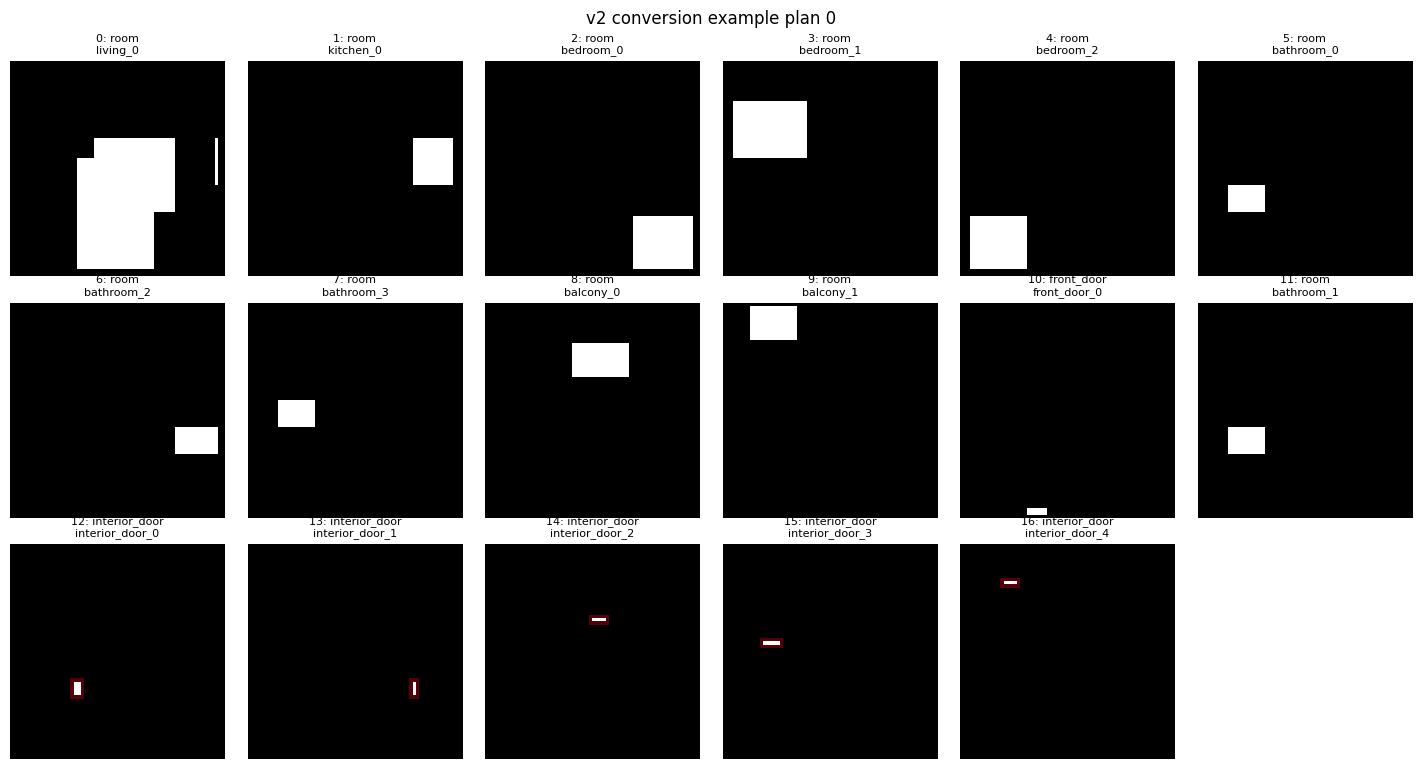

In [18]:
with open(DATASET_PATH, "rb") as f:
    plans = pickle.load(f)

print("Loaded plans:", len(plans))


def audit_dataset(plans, limit=1000):
    group_counts = Counter()
    type_counts = Counter()
    area_by_group = defaultdict(list)
    meta_sums = Counter()
    skip_reasons = Counter()
    valid_samples = 0

    for plan in tqdm(plans[:limit], desc="audit"):
        sample, meta = plan_to_sample_v2(
            plan,
            out_size=cfg["mask_size"],
            canvas_size=cfg["canvas_size"],
            door_match_buffer=cfg["door_match_buffer"],
            dilate_interior_train_mask=cfg["dilate_interior_train_mask"],
            min_room_nodes=cfg["min_room_nodes"],
            return_meta=True,
        )
        meta_sums.update({k: int(v) for k, v in meta.items() if isinstance(v, (int, np.integer))})
        if sample is None:
            skip_reasons[meta.get("skip_reason", "unknown")] += 1
            continue

        valid_samples += 1
        for gid in sample["node_groups"].tolist():
            group_counts[ID_TO_GROUP_NAME[int(gid)]] += 1
        for tid in sample["node_type_ids"].tolist():
            type_counts[int(tid)] += 1
        for gid, area in zip(sample["node_groups"].tolist(), sample["node_areas"].tolist()):
            area_by_group[ID_TO_GROUP_NAME[int(gid)]].append(float(area))

    print("Valid samples:", valid_samples, "/", min(limit, len(plans)))
    print("Skip reasons:", dict(skip_reasons))
    print("Node count by group:", dict(group_counts))
    print("Node count by type id:", dict(type_counts))
    print("Conversion counters:", dict(meta_sums))
    print("Area distribution by group:")
    for group_name, values in area_by_group.items():
        arr = np.asarray(values, dtype=np.float32)
        print(
            f"  {group_name:14s} count={len(arr):6d} "
            f"mean={arr.mean():.6f} median={np.median(arr):.6f} "
            f"p10={np.percentile(arr, 10):.6f} p90={np.percentile(arr, 90):.6f}"
        )


def find_valid_sample(plans, start=0):
    for idx in range(start, len(plans)):
        sample = plan_to_sample_v2(
            plans[idx],
            out_size=cfg["mask_size"],
            canvas_size=cfg["canvas_size"],
            door_match_buffer=cfg["door_match_buffer"],
            dilate_interior_train_mask=cfg["dilate_interior_train_mask"],
            min_room_nodes=cfg["min_room_nodes"],
        )
        if sample is not None:
            return idx, sample
    raise RuntimeError("No valid sample found.")


def visualize_sample(sample, max_nodes=24, title="sample"):
    n_nodes = min(max_nodes, sample["eval_mks"].shape[0])
    cols = min(6, n_nodes)
    rows = int(math.ceil(n_nodes / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.4 * cols, 2.6 * rows))
    axes = np.asarray(axes).reshape(rows, cols)

    eval_np = sample["eval_mks"][:n_nodes].cpu().numpy()
    train_np = sample["train_mks"][:n_nodes].cpu().numpy()
    for idx in range(rows * cols):
        ax = axes[idx // cols, idx % cols]
        ax.axis("off")
        if idx >= n_nodes:
            continue
        gid = int(sample["node_groups"][idx])
        group_name = ID_TO_GROUP_NAME[gid]
        name = sample["node_names"][idx]
        # Overlay train dilation in red for interior doors; raw eval in white.
        ax.imshow(eval_np[idx], cmap="gray", vmin=-1, vmax=1)
        if gid == GROUP_NAME_TO_ID["interior_door"]:
            dilated = ((train_np[idx] + 1) / 2) - ((eval_np[idx] + 1) / 2)
            ax.imshow(dilated, cmap="Reds", alpha=np.clip(dilated, 0, 1) * 0.8)
        ax.set_title(f"{idx}: {group_name}\n{name}", fontsize=8)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


if RUN_DATASET_AUDIT:
    audit_dataset(plans, limit=cfg["audit_plan_limit"])
    sample_idx, sample = find_valid_sample(plans)
    print("Visualizing valid plan index:", sample_idx)
    visualize_sample(sample, title=f"v2 conversion example plan {sample_idx}")


## 4. DataLoader

The split is deterministic: 90 percent train, 10 percent validation, with validation capped by `val_plan_limit`.


In [19]:
class CurriculumResPlanDataset(Dataset):
    def __init__(self, plans, out_size=64):
        self.plans = plans
        self.out_size = out_size

    def __len__(self):
        return len(self.plans)

    def __getitem__(self, idx):
        return plan_to_sample_v2(
            self.plans[idx],
            out_size=self.out_size,
            canvas_size=cfg["canvas_size"],
            door_match_buffer=cfg["door_match_buffer"],
            dilate_interior_train_mask=cfg["dilate_interior_train_mask"],
            min_room_nodes=cfg["min_room_nodes"],
        )


def resplan_collate_fn_v2(samples):
    samples = [sample for sample in samples if sample is not None]
    if not samples:
        return None

    all_train_mks = []
    all_eval_mks = []
    all_nds = []
    all_eds = []
    all_nd_to_sample = []
    all_ed_to_sample = []
    all_node_type_ids = []
    all_node_groups = []
    all_node_areas = []
    all_node_names = []

    node_offset = 0
    for sample_idx, sample in enumerate(samples):
        n_nodes = sample["nds"].shape[0]
        n_edges = sample["eds"].shape[0]

        all_train_mks.append(sample["train_mks"])
        all_eval_mks.append(sample["eval_mks"])
        all_nds.append(sample["nds"])
        all_node_type_ids.append(sample["node_type_ids"])
        all_node_groups.append(sample["node_groups"])
        all_node_areas.append(sample["node_areas"])
        all_node_names.extend(sample["node_names"])

        eds = sample["eds"].clone()
        if n_edges > 0:
            eds[:, 0] += node_offset
            eds[:, 2] += node_offset
            all_eds.append(eds)
            all_ed_to_sample.append(torch.full((n_edges,), sample_idx, dtype=torch.long))

        all_nd_to_sample.append(torch.full((n_nodes,), sample_idx, dtype=torch.long))
        node_offset += n_nodes

    return {
        "train_mks": torch.cat(all_train_mks, dim=0),
        "eval_mks": torch.cat(all_eval_mks, dim=0),
        "nds": torch.cat(all_nds, dim=0),
        "eds": torch.cat(all_eds, dim=0) if all_eds else torch.zeros((0, 3), dtype=torch.long),
        "nd_to_sample": torch.cat(all_nd_to_sample, dim=0),
        "ed_to_sample": torch.cat(all_ed_to_sample, dim=0) if all_ed_to_sample else torch.zeros((0,), dtype=torch.long),
        "node_type_ids": torch.cat(all_node_type_ids, dim=0),
        "node_groups": torch.cat(all_node_groups, dim=0),
        "node_areas": torch.cat(all_node_areas, dim=0),
        "node_names": all_node_names,
    }


def make_splits(plans, train_split=0.90, val_plan_limit=512, seed=11785):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(plans))
    n_train = int(len(indices) * train_split)
    train_indices = indices[:n_train]
    if val_plan_limit is None:
        val_indices = indices[n_train:]
    else:
        val_indices = indices[n_train:n_train + int(val_plan_limit)]
    return [plans[i] for i in train_indices], [plans[i] for i in val_indices]


train_plans, val_plans = make_splits(
    plans,
    train_split=cfg["train_split"],
    val_plan_limit=cfg["val_plan_limit"],
    seed=cfg["seed"],
)
if cfg.get("train_plan_limit") is not None:
    train_plans = train_plans[: int(cfg["train_plan_limit"])]


USE_DISK_SAMPLE_CACHE = bool(cfg.get("use_disk_sample_cache", False))
CACHE_DIR = Path(os.environ.get("RESPLAN_SAMPLE_CACHE_DIR", str(PROJECT_ROOT / "sample_cache")))
if USE_DISK_SAMPLE_CACHE:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)


def cache_token(value):
    return str(value).replace(".", "p").replace(os.sep, "-")


cache_name = "_".join(
    [
        "samples_v2",
        f"mask{cache_token(cfg['mask_size'])}",
        f"canvas{cache_token(cfg['canvas_size'])}",
        f"doorbuf{cache_token(cfg['door_match_buffer'])}",
        f"dilate{int(cfg['dilate_interior_train_mask'])}",
        f"minroom{cache_token(cfg['min_room_nodes'])}",
        f"split{cache_token(cfg['train_split'])}",
        f"seed{cache_token(cfg['seed'])}",
        f"trainlimit{cache_token(cfg.get('train_plan_limit', 'none'))}",
        f"vallimit{cache_token(cfg.get('val_plan_limit', 'none'))}",
    ]
)
TRAIN_CACHE_PATH = CACHE_DIR / f"{cache_name}_train.pt"
VAL_CACHE_PATH = CACHE_DIR / f"{cache_name}_val.pt"


def build_or_load_sample_cache(plans, cache_path, desc="cache"):
    cache_path = Path(cache_path)
    if USE_DISK_SAMPLE_CACHE and cache_path.exists():
        print("Loading sample cache:", cache_path)
        try:
            try:
                return torch.load(cache_path, map_location="cpu", weights_only=False)
            except TypeError:
                return torch.load(cache_path, map_location="cpu")
        except Exception as exc:
            print(f"Could not load sample cache ({exc}). Rebuilding it.")
            try:
                cache_path.unlink()
            except OSError:
                pass

    samples = []
    for plan in tqdm(plans, desc=desc):
        sample = plan_to_sample_v2(
            plan,
            out_size=cfg["mask_size"],
            canvas_size=cfg["canvas_size"],
            door_match_buffer=cfg["door_match_buffer"],
            dilate_interior_train_mask=cfg["dilate_interior_train_mask"],
            min_room_nodes=cfg["min_room_nodes"],
        )
        if sample is not None:
            samples.append(sample)

    if USE_DISK_SAMPLE_CACHE:
        print("Saving sample cache:", cache_path)
        try:
            torch.save(samples, cache_path)
        except Exception as exc:
            print(f"Could not save sample cache ({exc}). Continuing with in-memory samples only.")
            try:
                cache_path.unlink()
            except OSError:
                pass
    else:
        print(f"Disk sample cache disabled. Using {len(samples)} in-memory {desc} samples.")
    return samples


train_dataset = build_or_load_sample_cache(train_plans, TRAIN_CACHE_PATH, desc="cache train samples")
val_dataset = build_or_load_sample_cache(val_plans, VAL_CACHE_PATH, desc="cache val samples")

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg["batch_size"],
    shuffle=True,
    num_workers=cfg["num_workers"],
    collate_fn=resplan_collate_fn_v2,
    pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg["batch_size"],
    shuffle=False,
    num_workers=cfg["num_workers"],
    collate_fn=resplan_collate_fn_v2,
    pin_memory=(device.type == "cuda"),
)

print("Train plans:", len(train_plans))
print("Val plans:", len(val_plans))
first_batch = None
for candidate_batch in train_loader:
    if candidate_batch is not None:
        first_batch = candidate_batch
        break
if first_batch is None:
    raise RuntimeError("No valid training batch found. Check data conversion filters.")
print("First batch nodes:", first_batch["nds"].shape[0], "edges:", first_batch["eds"].shape[0])
print("Batch fields:", list(first_batch.keys()))


Train plans: 15300
Val plans: 512
First batch nodes: 205 edges: 1279
Batch fields: ['train_mks', 'eval_mks', 'nds', 'eds', 'nd_to_sample', 'ed_to_sample', 'node_type_ids', 'node_groups', 'node_areas', 'node_names']


## 5. Fixed Node Strategy

Only room nodes can be fixed. Front doors and interior doors are never hard-copied as fixed targets.


In [20]:
def batch_to_device(batch, device):
    out = {}
    for key, value in batch.items():
        if torch.is_tensor(value):
            out[key] = value.to(device, non_blocking=True)
        else:
            out[key] = value
    return out


def select_fixed_room_nodes(nd_to_sample, node_groups, node_areas, fixed_room_keep_prob=0.35):
    device = node_groups.device
    fixed_nodes = []
    batch_size = int(nd_to_sample.max().item()) + 1 if nd_to_sample.numel() else 0
    for sample_idx in range(batch_size):
        sample_mask = nd_to_sample == sample_idx
        room_mask = sample_mask & (node_groups == GROUP_NAME_TO_ID["room"])
        room_nodes = torch.nonzero(room_mask, as_tuple=False).flatten()
        if room_nodes.numel() == 0:
            continue

        keep = torch.rand(room_nodes.numel(), device=device) < fixed_room_keep_prob
        chosen = room_nodes[keep]
        if chosen.numel() == 0:
            largest_local = torch.argmax(node_areas[room_nodes])
            chosen = room_nodes[largest_local:largest_local + 1]
        fixed_nodes.append(chosen)

    if fixed_nodes:
        fixed_nodes = torch.cat(fixed_nodes).long()
    else:
        fixed_nodes = torch.empty((0,), dtype=torch.long, device=device)
    return fixed_nodes


def build_given_masks(real_masks, fixed_nodes):
    n_nodes, height, width = real_masks.shape
    given_values = torch.full_like(real_masks, -1.0)
    fixed_flags = torch.zeros_like(real_masks)
    if fixed_nodes.numel() > 0:
        given_values[fixed_nodes] = real_masks[fixed_nodes]
        fixed_flags[fixed_nodes] = 1.0
    return torch.stack([given_values, fixed_flags], dim=1)


def hard_copy_fixed_masks(pred_masks, real_masks, fixed_nodes):
    if fixed_nodes.numel() == 0:
        return pred_masks
    out = pred_masks.clone()
    out[fixed_nodes] = real_masks[fixed_nodes]
    return out


def make_active_mask(node_groups, fixed_nodes, active_groups):
    active_ids = torch.tensor(
        [GROUP_NAME_TO_ID[name] for name in active_groups],
        dtype=torch.long,
        device=node_groups.device,
    )
    active = torch.isin(node_groups, active_ids)
    if fixed_nodes.numel() > 0:
        active[fixed_nodes] = False
    return active


def make_fixed_mask(num_nodes, fixed_nodes, device):
    fixed_mask = torch.zeros((num_nodes,), dtype=torch.bool, device=device)
    if fixed_nodes.numel() > 0:
        fixed_mask[fixed_nodes] = True
    return fixed_mask


def init_generator_inputs(batch):
    fixed_nodes = select_fixed_room_nodes(
        batch["nd_to_sample"],
        batch["node_groups"],
        batch["node_areas"],
        fixed_room_keep_prob=cfg["fixed_room_keep_prob"],
    )
    given_m = build_given_masks(batch["train_mks"], fixed_nodes)
    z = torch.randn(batch["nds"].shape[0], 128, device=batch["nds"].device)
    return z, given_m, fixed_nodes


## 6. Loss And Metrics

Reconstruction is active-node only for the main loss, plus a small fixed-room preservation loss.

Per-node loss:

`weighted_l1 + 5*dice + 5*area + 3*empty + 2*oversize`


In [21]:
GROUP_LOSS_WEIGHTS = torch.tensor([1.0, 2.0, 4.0], dtype=torch.float32)


def tanh_to_prob(x):
    return ((x + 1.0) * 0.5).clamp(0.0, 1.0)


def grouped_recon_loss(pred, target, node_groups, active_mask, eps=1e-6):
    active_mask = active_mask.bool()
    if active_mask.sum().item() == 0:
        zero = pred.sum() * 0.0
        return zero, {
            "l1": 0.0,
            "dice": 0.0,
            "area": 0.0,
            "empty": 0.0,
            "oversize": 0.0,
            "nodes": 0,
        }

    pred_prob = tanh_to_prob(pred)
    target_prob = tanh_to_prob(target)
    n_nodes, height, width = pred_prob.shape
    pixel_count = float(height * width)

    pos_weight = torch.where(
        node_groups == GROUP_NAME_TO_ID["interior_door"],
        torch.tensor(80.0, device=pred.device),
        torch.tensor(30.0, device=pred.device),
    )
    pixel_weight = 1.0 + (pos_weight.view(-1, 1, 1) - 1.0) * target_prob
    l1_node = (torch.abs(pred_prob - target_prob) * pixel_weight).flatten(1).mean(dim=1)

    inter = (pred_prob * target_prob).flatten(1).sum(dim=1)
    pred_sum = pred_prob.flatten(1).sum(dim=1)
    target_sum = target_prob.flatten(1).sum(dim=1)
    dice_node = 1.0 - (2.0 * inter + eps) / (pred_sum + target_sum + eps)

    pred_area = pred_sum / pixel_count
    target_area = target_sum / pixel_count
    area_denom = target_area + (1.0 / pixel_count)
    area_node = torch.abs(pred_area - target_area) / area_denom
    empty_node = F.relu(0.5 * target_area - pred_area) / area_denom
    oversize_node = F.relu(pred_area - 2.0 * target_area) / area_denom

    node_loss = (
        l1_node
        + 5.0 * dice_node
        + 5.0 * area_node
        + 3.0 * empty_node
        + 2.0 * oversize_node
    )

    group_weights = GROUP_LOSS_WEIGHTS.to(pred.device)[node_groups]
    weights = group_weights * active_mask.float()
    loss = (node_loss * weights).sum() / (weights.sum() + eps)

    def masked_mean(values):
        return float(values[active_mask].detach().mean().cpu().item())

    logs = {
        "l1": masked_mean(l1_node),
        "dice": masked_mean(dice_node),
        "area": masked_mean(area_node),
        "empty": masked_mean(empty_node),
        "oversize": masked_mean(oversize_node),
        "nodes": int(active_mask.sum().item()),
    }
    return loss, logs


def metric_sums(pred, target, node_groups, active_mask, threshold=0.5, eps=1e-6):
    active_mask = active_mask.bool()
    pred_prob = tanh_to_prob(pred)
    target_prob = tanh_to_prob(target)
    pred_bin = pred_prob > threshold
    target_bin = target_prob > threshold

    inter = (pred_bin & target_bin).flatten(1).sum(dim=1).float()
    union = (pred_bin | target_bin).flatten(1).sum(dim=1).float()
    iou = inter / (union + eps)

    pred_area = pred_bin.flatten(1).float().mean(dim=1)
    target_area = target_bin.flatten(1).float().mean(dim=1)
    min_pixel_area = 1.0 / float(pred.shape[-1] * pred.shape[-2])
    empty = pred_area <= (0.5 * min_pixel_area)
    oversized = pred_area > torch.maximum(2.0 * target_area, target_area + min_pixel_area)

    sums = defaultdict(float)
    counts = defaultdict(int)

    active_count = int(active_mask.sum().item())
    counts["active"] = active_count
    if active_count > 0:
        sums["active_iou"] = float(iou[active_mask].sum().detach().cpu().item())
        sums["active_empty"] = float(empty[active_mask].float().sum().detach().cpu().item())
        sums["active_oversized"] = float(oversized[active_mask].float().sum().detach().cpu().item())
        sums["active_pred_area"] = float(pred_area[active_mask].sum().detach().cpu().item())
        sums["active_target_area"] = float(target_area[active_mask].sum().detach().cpu().item())

    for group_id, group_name in ID_TO_GROUP_NAME.items():
        mask = active_mask & (node_groups == group_id)
        count = int(mask.sum().item())
        counts[group_name] = count
        if count > 0:
            sums[f"{group_name}_iou"] = float(iou[mask].sum().detach().cpu().item())

    return sums, counts


def finalize_metric_sums(total_sums, total_counts):
    active_count = max(int(total_counts.get("active", 0)), 1)
    metrics = {
        "active_iou_mean": total_sums.get("active_iou", 0.0) / active_count,
        "active_empty_rate": total_sums.get("active_empty", 0.0) / active_count,
        "active_oversized_rate": total_sums.get("active_oversized", 0.0) / active_count,
        "active_pred_area_mean": total_sums.get("active_pred_area", 0.0) / active_count,
        "active_target_area_mean": total_sums.get("active_target_area", 0.0) / active_count,
    }
    for group_name in ("room", "front_door", "interior_door"):
        count = int(total_counts.get(group_name, 0))
        metrics[f"{group_name}_iou_mean"] = (
            total_sums.get(f"{group_name}_iou", 0.0) / count if count > 0 else float("nan")
        )
    return metrics


## 7. Model / Checkpoint

The model architecture is unchanged. This notebook changes data construction, conditioning, loss, metrics, and phase control.


In [22]:
def resolve_checkpoint_path(load_checkpoint):
    if not load_checkpoint:
        return None
    candidate = Path(str(load_checkpoint))
    if candidate.exists():
        return candidate

    alias_to_phase = {
        "phase_a1_best": "phase_a1_rooms",
        "phase_a2_best": "phase_a2_frontdoor",
        "phase_a3_best": "phase_a3_matched_doors",
    }
    phase_name = alias_to_phase.get(str(load_checkpoint))
    if phase_name is None:
        raise FileNotFoundError(f"Unknown checkpoint alias/path: {load_checkpoint}")

    matches = sorted(
        CHECKPOINT_ROOT.glob(f"graphgps_curriculum_{phase_name}_*/best.pth"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not matches:
        raise FileNotFoundError(f"No best checkpoint found for alias {load_checkpoint}")
    return matches[0]


def save_checkpoint(path, epoch, generator, optimizer_g, metrics, discriminator=None, optimizer_d=None):
    payload = {
        "epoch": epoch,
        "selected_phase": selected_phase,
        "cfg": cfg,
        "metrics": metrics,
        "generator": generator.state_dict(),
        "optimizer_g": optimizer_g.state_dict(),
    }
    if discriminator is not None:
        payload["discriminator"] = discriminator.state_dict()
    if optimizer_d is not None:
        payload["optimizer_d"] = optimizer_d.state_dict()
    torch.save(payload, path)


def load_generator_checkpoint(generator, checkpoint_path, optimizer_g=None, strict=True):
    checkpoint_path = Path(checkpoint_path)
    payload = torch.load(checkpoint_path, map_location=device)
    state = payload.get("generator", payload)
    generator.load_state_dict(state, strict=strict)
    if optimizer_g is not None and "optimizer_g" in payload:
        optimizer_g.load_state_dict(payload["optimizer_g"])
    print("Loaded generator checkpoint:", checkpoint_path)
    return payload


generator = Generator().to(device)
discriminator = Discriminator().to(device) if cfg.get("d_lr", 0.0) > 0 else None

optimizer_g = torch.optim.Adam(generator.parameters(), lr=cfg["g_lr"], betas=(0.5, 0.999))
optimizer_d = (
    torch.optim.Adam(discriminator.parameters(), lr=cfg["d_lr"], betas=(0.5, 0.999))
    if discriminator is not None
    else None
)

load_path = resolve_checkpoint_path(cfg.get("load_checkpoint"))
if load_path is not None:
    load_generator_checkpoint(generator, load_path, optimizer_g=None, strict=True)

wandb_run = None
if cfg.get("use_wandb", False):
    import wandb
    wandb_run = wandb.init(project=cfg["wandb_project"], name=RUN_NAME, config=cfg)

print("Model:", MODEL_NAME)
print("Generator params:", sum(p.numel() for p in generator.parameters()))
print("Discriminator enabled:", discriminator is not None)


wandb: Currently logged in as: jfu2 (jfu2-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Model: graphgps
Generator params: 667121
Discriminator enabled: False


## 8. Small-Batch Overfit Sanity Check

Before formal training, turn this on and confirm A1 can overfit 8 plans. A healthy pipeline should push `room_iou_mean` above roughly `0.70`.


In [23]:
def collect_valid_samples(plans, n_samples):
    out = []
    for plan in plans:
        sample = plan_to_sample_v2(
            plan,
            out_size=cfg["mask_size"],
            canvas_size=cfg["canvas_size"],
            door_match_buffer=cfg["door_match_buffer"],
            dilate_interior_train_mask=cfg["dilate_interior_train_mask"],
            min_room_nodes=cfg["min_room_nodes"],
        )
        if sample is not None:
            out.append(sample)
        if len(out) >= n_samples:
            break
    return out


def run_small_batch_overfit(steps=200, n_samples=8):
    local_cfg = dict(cfg)
    local_cfg["active_groups"] = ["room"]
    samples = collect_valid_samples(train_plans, n_samples)
    loader = DataLoader(samples, batch_size=n_samples, shuffle=False, collate_fn=resplan_collate_fn_v2)
    batch = batch_to_device(next(iter(loader)), device)

    model = Generator().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.5, 0.999))
    history = []

    for step in tqdm(range(steps), desc="small-batch overfit"):
        model.train()
        z, given_m, fixed_nodes = init_generator_inputs(batch)
        pred = model(z, given_m=given_m, given_y=batch["nds"].float(), given_w=batch["eds"].long())
        active_mask = make_active_mask(batch["node_groups"], fixed_nodes, local_cfg["active_groups"])
        fixed_mask = make_fixed_mask(pred.shape[0], fixed_nodes, device) & (batch["node_groups"] == GROUP_NAME_TO_ID["room"])
        main_loss, _ = grouped_recon_loss(pred, batch["train_mks"], batch["node_groups"], active_mask)
        fixed_loss, _ = grouped_recon_loss(pred, batch["train_mks"], batch["node_groups"], fixed_mask)
        loss = main_loss + local_cfg["fixed_preserve_weight"] * fixed_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if (step + 1) % 25 == 0 or step == steps - 1:
            with torch.no_grad():
                pred_cond = hard_copy_fixed_masks(pred, batch["eval_mks"], fixed_nodes)
                sums, counts = metric_sums(
                    pred_cond,
                    batch["eval_mks"],
                    batch["node_groups"],
                    active_mask,
                    threshold=cfg["threshold"],
                )
                metrics = finalize_metric_sums(sums, counts)
                history.append((step + 1, float(loss.detach().cpu().item()), metrics["room_iou_mean"]))
                print(f"step {step+1:04d} loss={history[-1][1]:.4f} room_iou={history[-1][2]:.4f}")
    return model, batch, history


if RUN_SMALL_BATCH_OVERFIT:
    overfit_model, overfit_batch, overfit_history = run_small_batch_overfit(steps=200, n_samples=8)


## 9. Training Loop

Best checkpoint is selected by highest `val_active_iou_mean`.


In [ ]:
def amp_dtype_from_cfg():
    dtype_name = str(cfg.get("amp_dtype", "bf16")).lower()
    if dtype_name in {"fp16", "float16"}:
        return torch.float16
    return torch.bfloat16


def amp_autocast():
    if not (cfg.get("use_amp", False) and device.type == "cuda"):
        return contextlib.nullcontext()
    return torch.autocast(device_type="cuda", dtype=amp_dtype_from_cfg())


def train_one_epoch(epoch):
    generator.train()
    if discriminator is not None:
        discriminator.train()

    running = Counter()
    num_batches = 0
    use_gan = discriminator is not None and cfg.get("d_lr", 0.0) > 0

    for batch in tqdm(train_loader, desc=f"train {epoch}"):
        if batch is None:
            continue
        batch = batch_to_device(batch, device)
        num_batches += 1

        z, given_m, fixed_nodes = init_generator_inputs(batch)
        with amp_autocast():
            pred_raw = generator(
                z,
                given_m=given_m,
                given_y=batch["nds"].float(),
                given_w=batch["eds"].long(),
            )
        pred_for_disc = (
            hard_copy_fixed_masks(pred_raw, batch["train_mks"], fixed_nodes)
            if cfg.get("hard_copy_fixed_nodes", False)
            else pred_raw
        )

        active_mask = make_active_mask(batch["node_groups"], fixed_nodes, cfg["active_groups"])
        fixed_mask = make_fixed_mask(pred_raw.shape[0], fixed_nodes, device) & (
            batch["node_groups"] == GROUP_NAME_TO_ID["room"]
        )

        if use_gan:
            for _ in range(int(cfg.get("n_critic", 1))):
                optimizer_d.zero_grad(set_to_none=True)
                with amp_autocast():
                    d_real = discriminator(
                        batch["train_mks"],
                        batch["nds"].float(),
                        batch["eds"].long(),
                        batch["nd_to_sample"].long(),
                    )
                    d_fake = discriminator(
                        pred_for_disc.detach(),
                        batch["nds"].float(),
                        batch["eds"].long(),
                        batch["nd_to_sample"].long(),
                    )
                    gp = compute_gradient_penalty(
                        discriminator,
                        batch["train_mks"],
                        pred_for_disc.detach(),
                        given_y=batch["nds"].float(),
                        given_w=batch["eds"].long(),
                        nd_to_sample=batch["nd_to_sample"].long(),
                    )
                    d_loss = d_fake.mean() - d_real.mean() + cfg["lambda_gp"] * gp
                d_loss.backward()
                optimizer_d.step()
                running["d_loss"] += float(d_loss.detach().cpu().item())

        with amp_autocast():
            main_loss, main_logs = grouped_recon_loss(
                pred_raw,
                batch["train_mks"],
                batch["node_groups"],
                active_mask,
            )
            fixed_loss, fixed_logs = grouped_recon_loss(
                pred_raw,
                batch["train_mks"],
                batch["node_groups"],
                fixed_mask,
            )

        if use_gan:
            with amp_autocast():
                g_adv = -discriminator(
                    pred_for_disc,
                    batch["nds"].float(),
                    batch["eds"].long(),
                    batch["nd_to_sample"].long(),
                ).mean()
            g_loss = (
                cfg.get("gan_nonfixed_recon_weight", 15.0) * main_loss
                + cfg.get("gan_recon_weight", 10.0) * fixed_loss
                + cfg.get("gan_adv_weight", 0.0005) * g_adv
            )
            running["g_adv"] += float(g_adv.detach().cpu().item())
        else:
            g_loss = main_loss + cfg["fixed_preserve_weight"] * fixed_loss

        optimizer_g.zero_grad(set_to_none=True)
        g_loss.backward()
        if cfg.get("grad_clip_norm"):
            torch.nn.utils.clip_grad_norm_(generator.parameters(), cfg["grad_clip_norm"])
        optimizer_g.step()

        running["g_loss"] += float(g_loss.detach().cpu().item())
        running["main_loss"] += float(main_loss.detach().cpu().item())
        running["fixed_loss"] += float(fixed_loss.detach().cpu().item())
        for key, value in main_logs.items():
            if key != "nodes":
                running[f"main_{key}"] += float(value)

    denom = max(num_batches, 1)
    return {key: value / denom for key, value in running.items()}


@torch.no_grad()
def validate(epoch):
    generator.eval()
    total_sums = Counter()
    total_counts = Counter()
    running = Counter()
    num_batches = 0

    for batch in tqdm(val_loader, desc=f"val {epoch}"):
        if batch is None:
            continue
        batch = batch_to_device(batch, device)
        num_batches += 1

        z, given_m, fixed_nodes = init_generator_inputs(batch)
        with amp_autocast():
            pred_raw = generator(
                z,
                given_m=given_m,
                given_y=batch["nds"].float(),
                given_w=batch["eds"].long(),
            )
        pred_eval = (
            hard_copy_fixed_masks(pred_raw, batch["eval_mks"], fixed_nodes)
            if cfg.get("hard_copy_fixed_nodes", False)
            else pred_raw
        )

        active_mask = make_active_mask(batch["node_groups"], fixed_nodes, cfg["active_groups"])
        fixed_mask = make_fixed_mask(pred_raw.shape[0], fixed_nodes, device) & (
            batch["node_groups"] == GROUP_NAME_TO_ID["room"]
        )
        with amp_autocast():
            main_loss, _ = grouped_recon_loss(pred_raw, batch["train_mks"], batch["node_groups"], active_mask)
            fixed_loss, _ = grouped_recon_loss(pred_raw, batch["train_mks"], batch["node_groups"], fixed_mask)
        running["val_main_loss"] += float(main_loss.detach().cpu().item())
        running["val_fixed_loss"] += float(fixed_loss.detach().cpu().item())

        sums, counts = metric_sums(
            pred_eval,
            batch["eval_mks"],
            batch["node_groups"],
            active_mask,
            threshold=cfg["threshold"],
        )
        total_sums.update(sums)
        total_counts.update(counts)

    metrics = finalize_metric_sums(total_sums, total_counts)
    denom = max(num_batches, 1)
    for key, value in running.items():
        metrics[key] = value / denom
    return metrics


def print_epoch_summary(epoch, train_logs, val_metrics):
    parts = [
        f"epoch {epoch:03d}",
        f"g_loss={train_logs.get('g_loss', 0.0):.4f}",
        f"main={train_logs.get('main_loss', 0.0):.4f}",
        f"val_active_iou={val_metrics['active_iou_mean']:.4f}",
        f"room_iou={val_metrics['room_iou_mean']:.4f}",
        f"front_iou={val_metrics['front_door_iou_mean']:.4f}",
        f"door_iou={val_metrics['interior_door_iou_mean']:.4f}",
        f"empty={val_metrics['active_empty_rate']:.3f}",
        f"oversize={val_metrics['active_oversized_rate']:.3f}",
    ]
    print(" | ".join(parts))


@torch.no_grad()
def make_wandb_preview(epoch, max_nodes=None):
    max_nodes = int(max_nodes or cfg.get("wandb_preview_max_nodes", 8))
    if max_nodes <= 0:
        return None

    was_training = generator.training
    generator.eval()

    batch = None
    for candidate_batch in val_loader:
        if candidate_batch is not None:
            batch = batch_to_device(candidate_batch, device)
            break
    if batch is None:
        if was_training:
            generator.train()
        return None

    z, given_m, fixed_nodes = init_generator_inputs(batch)
    with amp_autocast():
        pred_raw = generator(
            z,
            given_m=given_m,
            given_y=batch["nds"].float(),
            given_w=batch["eds"].long(),
        )
    pred_cond = (
        hard_copy_fixed_masks(pred_raw, batch["eval_mks"], fixed_nodes)
        if cfg.get("hard_copy_fixed_nodes", False)
        else pred_raw
    )

    active_mask = make_active_mask(batch["node_groups"], fixed_nodes, cfg["active_groups"])
    selected = torch.where(active_mask.detach().cpu())[0].tolist()
    if not selected:
        selected = list(range(batch["eval_mks"].shape[0]))
    selected = selected[:max_nodes]
    if not selected:
        if was_training:
            generator.train()
        return None

    pred_bin = tanh_to_prob(pred_cond) > cfg["threshold"]
    target_bin = tanh_to_prob(batch["eval_mks"]) > cfg["threshold"]
    inter = (pred_bin & target_bin).flatten(1).sum(dim=1).float()
    union = (pred_bin | target_bin).flatten(1).sum(dim=1).float()
    node_iou = (inter / (union + 1e-6)).detach().cpu().numpy()

    target_np = tanh_to_prob(batch["eval_mks"]).detach().float().cpu().numpy()
    raw_np = tanh_to_prob(pred_raw).detach().float().cpu().numpy()
    cond_np = tanh_to_prob(pred_cond).detach().float().cpu().numpy()
    fixed_set = set(fixed_nodes.detach().cpu().tolist())

    n_nodes = len(selected)
    fig, axes = plt.subplots(3, n_nodes, figsize=(1.8 * n_nodes, 5.2), squeeze=False)
    rows = [("target", target_np), ("raw", raw_np), ("cond", cond_np)]
    for col, node_idx in enumerate(selected):
        group_name = ID_TO_GROUP_NAME[int(batch["node_groups"][node_idx])]
        fixed_tag = " fixed" if node_idx in fixed_set else ""
        node_name = batch["node_names"][node_idx]
        for row_idx, (row_name, arr) in enumerate(rows):
            ax = axes[row_idx, col]
            ax.imshow(arr[node_idx], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if row_idx == 0:
                ax.set_title(
                    f"{node_idx}: {group_name}{fixed_tag}\n{node_name}\niou={node_iou[node_idx]:.3f}",
                    fontsize=7,
                )
            if col == 0:
                ax.set_ylabel(row_name, fontsize=8)
    fig.suptitle(f"epoch {epoch:03d} preview", fontsize=10)
    fig.tight_layout()

    if was_training:
        generator.train()
    return fig


def train_curriculum_phase():
    best_score = -float("inf")
    history = []

    for epoch in range(1, int(cfg["epochs"]) + 1):
        train_logs = train_one_epoch(epoch)
        val_metrics = validate(epoch)
        score = val_metrics["active_iou_mean"]

        save_checkpoint(
            CHECKPOINT_DIR / "last.pth",
            epoch,
            generator,
            optimizer_g,
            val_metrics,
            discriminator=discriminator,
            optimizer_d=optimizer_d,
        )
        if score > best_score:
            best_score = score
            save_checkpoint(
                CHECKPOINT_DIR / "best.pth",
                epoch,
                generator,
                optimizer_g,
                val_metrics,
                discriminator=discriminator,
                optimizer_d=optimizer_d,
            )
            print(f"new best val_active_iou_mean={best_score:.4f}")

        row = {"epoch": epoch, **{f"train_{k}": v for k, v in train_logs.items()}, **{f"val_{k}": v for k, v in val_metrics.items()}}
        history.append(row)
        print_epoch_summary(epoch, train_logs, val_metrics)

        if wandb_run is not None:
            wandb_row = dict(row)
            preview_every = int(cfg.get("wandb_preview_every", 1))
            if preview_every > 0 and epoch % preview_every == 0:
                preview_fig = make_wandb_preview(epoch)
                if preview_fig is not None:
                    wandb_row["preview"] = wandb.Image(preview_fig)
                    plt.close(preview_fig)
            wandb_run.log(wandb_row)

        with open(OUTPUT_DIR / "history.json", "w", encoding="utf-8") as f:
            json.dump(history, f, indent=2)

    print("Best checkpoint:", CHECKPOINT_DIR / "best.pth")
    print("Last checkpoint:", CHECKPOINT_DIR / "last.pth")
    return history


if RUN_TRAINING:
    history = train_curriculum_phase()
else:
    print("RUN_TRAINING is False. Set it to True after audit/sanity checks.")


train 1:   0%|          | 0/957 [00:00<?, ?it/s]

## 10. Phase Gates

Recommended progression:

- A1 -> A2: `val_room_iou_mean >= 0.45` and `active_empty_rate < 0.25`.
- A2 -> A3: `val_room_iou_mean >= 0.45`, `val_front_door_iou_mean > 0.10`, and `active_empty_rate < 0.25`.
- A3 -> B: `val_room_iou_mean >= 0.50`, `val_active_iou_mean >= 0.35`, `active_empty_rate < 0.25`, and `active_oversized_rate < 0.35`.

Phase B is optional. If it drops `val_active_iou_mean` by more than `0.05` from A3 best, stop and use A3 best.


In [14]:
def evaluate_phase_gate(metrics, phase_name):
    def get_metric(key, default):
        return metrics.get(key, metrics.get(f"val_{key}", default))

    if phase_name == "phase_a1_rooms":
        passed = get_metric("room_iou_mean", 0.0) >= 0.45 and get_metric("active_empty_rate", 1.0) < 0.25
        message = "A1 -> A2" if passed else "Stay in A1; consider +10 epochs at lr=5e-5."
    elif phase_name == "phase_a2_frontdoor":
        passed = (
            get_metric("room_iou_mean", 0.0) >= 0.45
            and get_metric("front_door_iou_mean", 0.0) > 0.10
            and get_metric("active_empty_rate", 1.0) < 0.25
        )
        message = "A2 -> A3" if passed else "Stay in A2 or inspect front-door masks."
    elif phase_name == "phase_a3_matched_doors":
        passed = (
            get_metric("room_iou_mean", 0.0) >= 0.50
            and get_metric("active_iou_mean", 0.0) >= 0.35
            and get_metric("active_empty_rate", 1.0) < 0.25
            and get_metric("active_oversized_rate", 1.0) < 0.35
        )
        message = "A3 -> optional Phase B" if passed else "Keep supervised A3; do not start GAN yet."
    else:
        passed = False
        message = "No gate for this phase."
    return passed, message


# Example after training:
# passed, message = evaluate_phase_gate(history[-1], selected_phase)
# print(passed, message)


## 11. Inference / Visualization

This visualization shows fixed rooms, real eval masks, generated raw masks, and generated conditioned masks with group labels and node IoU.


In [15]:
@torch.no_grad()
def visualize_predictions(checkpoint="best", batch_index=0, max_nodes=24):
    if checkpoint == "best":
        checkpoint_path = CHECKPOINT_DIR / "best.pth"
    elif checkpoint == "last":
        checkpoint_path = CHECKPOINT_DIR / "last.pth"
    else:
        checkpoint_path = Path(checkpoint)

    infer_generator = Generator().to(device)
    if checkpoint_path.exists():
        load_generator_checkpoint(infer_generator, checkpoint_path, strict=True)
    else:
        print("Checkpoint not found, using current generator weights:", checkpoint_path)
        infer_generator.load_state_dict(generator.state_dict())
    infer_generator.eval()

    for idx, batch in enumerate(val_loader):
        if batch is None:
            continue
        if idx < batch_index:
            continue
        batch = batch_to_device(batch, device)
        break

    z, given_m, fixed_nodes = init_generator_inputs(batch)
    pred_raw = infer_generator(
        z,
        given_m=given_m,
        given_y=batch["nds"].float(),
        given_w=batch["eds"].long(),
    )
    pred_cond = (
        hard_copy_fixed_masks(pred_raw, batch["eval_mks"], fixed_nodes)
        if cfg.get("hard_copy_fixed_nodes", False)
        else pred_raw
    )

    pred_bin = tanh_to_prob(pred_cond) > cfg["threshold"]
    target_bin = tanh_to_prob(batch["eval_mks"]) > cfg["threshold"]
    inter = (pred_bin & target_bin).flatten(1).sum(dim=1).float()
    union = (pred_bin | target_bin).flatten(1).sum(dim=1).float()
    node_iou = (inter / (union + 1e-6)).detach().cpu().numpy()

    n_nodes = min(max_nodes, batch["eval_mks"].shape[0])
    fixed_set = set(fixed_nodes.detach().cpu().tolist())
    fig, axes = plt.subplots(4, n_nodes, figsize=(2.0 * n_nodes, 8.0))
    if n_nodes == 1:
        axes = np.asarray(axes).reshape(4, 1)

    given_np = given_m[:, 0].detach().cpu().numpy()
    real_np = batch["eval_mks"].detach().cpu().numpy()
    raw_np = pred_raw.detach().cpu().numpy()
    cond_np = pred_cond.detach().cpu().numpy()
    groups_np = batch["node_groups"].detach().cpu().numpy()

    row_titles = ["fixed/given", "real eval", "gen raw", "gen conditioned"]
    for col in range(n_nodes):
        for row, arr in enumerate([given_np, real_np, raw_np, cond_np]):
            ax = axes[row, col]
            ax.axis("off")
            ax.imshow(arr[col], cmap="gray", vmin=-1, vmax=1)
            if col == 0:
                ax.set_ylabel(row_titles[row], fontsize=9)

        group_name = ID_TO_GROUP_NAME[int(groups_np[col])]
        fixed_mark = " fixed" if col in fixed_set else ""
        axes[0, col].set_title(
            f"{col}: {group_name}{fixed_mark}\nIoU={node_iou[col]:.3f}",
            fontsize=8,
        )

    plt.suptitle(f"Predictions from {checkpoint_path.name if checkpoint_path.exists() else 'current weights'}")
    plt.tight_layout()
    plt.show()


# After a checkpoint exists:
# visualize_predictions(checkpoint="best", batch_index=0, max_nodes=16)


## 12. Smoke Test Checklist

Before formal training:

1. Run dataset audit.
2. Confirm `skipped_unmatched_doors` is recorded and interior-door count is lower than the old notebook.
3. Visualize 8 random plans and check room/front-door/interior-door alignment.
4. Run the small-batch A1 overfit check.
5. Run A1/A2/A3 smoke tests with `epochs=1` if you changed core code.
